# 05 - Preguntas Analíticas - Catastro DNC

En este notebook se responden preguntas analíticas sobre el modelo de Catastro construido en las etapas anteriores.

Las consultas se realizan sobre las tablas Hive de la base `obligatorio_catastro`, creadas a partir del modelo curated ubicado en `/cur/obligatorio_catastro`.

Los resultados principales se guardarán en la zona analítica del datalake:

`/anl/obligatorio_catastro`

## 1. Inicialización del entorno Spark con soporte Hive

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder \
    .appName("Obligatorio Catastro - Preguntas Analiticas") \
    .enableHiveSupport() \
    .getOrCreate()

spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


2026-06-05T04:33:09,050 WARN [Thread-4] org.apache.hadoop.util.NativeCodeLoader - Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 2. Definición de base Hive y ruta analítica

Se define la base Hive que contiene el modelo analítico y la ruta HDFS donde se almacenarán los resultados de las preguntas.

In [2]:
HIVE_DB = "obligatorio_catastro"
ANL_PATH = "/anl/obligatorio_catastro"

spark.sql(f"USE {HIVE_DB}")

print("Base Hive:", HIVE_DB)
print("Ruta ANL:", ANL_PATH)

2026-06-05T04:33:16,269 INFO [Thread-4] org.apache.hadoop.hive.conf.HiveConf - Found configuration file file:/home/ort/spark/conf/hive-site.xml
2026-06-05T04:33:16,500 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.metastore.wm.default.pool.size does not exist
2026-06-05T04:33:16,500 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.llap.task.scheduler.preempt.independent does not exist
2026-06-05T04:33:16,500 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.llap.output.format.arrow does not exist
2026-06-05T04:33:16,500 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.tez.llap.min.reducer.per.executor does not exist
2026-06-05T04:33:16,500 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.arrow.root.allocator.limit does not exist
2026-06-05T04:33:16,500 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.vectorized.use.che

## 3. Validación inicial de tablas disponibles

Antes de responder las preguntas analíticas, se valida que las tablas Hive del modelo estén disponibles.

In [3]:
spark.sql("SHOW TABLES").show(50, truncate=False)

[Stage 0:>                                                          (0 + 1) / 1]

+--------------------+--------------------------+-----------+
|namespace           |tableName                 |isTemporary|
+--------------------+--------------------------+-----------+
|obligatorio_catastro|dim_categoria_construccion|false      |
|obligatorio_catastro|dim_cielorraso            |false      |
|obligatorio_catastro|dim_cubierta              |false      |
|obligatorio_catastro|dim_departamento          |false      |
|obligatorio_catastro|dim_destino               |false      |
|obligatorio_catastro|dim_estado_conservacion   |false      |
|obligatorio_catastro|dim_localidad             |false      |
|obligatorio_catastro|dim_tipo_obra             |false      |
|obligatorio_catastro|fact_historico_valores    |false      |
|obligatorio_catastro|fact_lineas_construccion  |false      |
|obligatorio_catastro|fact_padrones_rurales     |false      |
|obligatorio_catastro|fact_padrones_urbanos     |false      |
+--------------------+--------------------------+-----------+



## 4. Preguntas analíticas

A partir del modelo Hive de Catastro, se definen las siguientes preguntas analíticas:

1. ¿Qué departamentos concentran mayor valor catastral urbano?
2. ¿Cuál es el valor catastral urbano promedio por metro cuadrado edificado en cada departamento?
3. ¿Qué destinos de construcción concentran mayor área construida?
4. ¿Cómo se distribuyen las líneas de construcción según estado de conservación?
5. ¿Qué departamentos concentran mayor superficie rural y valor catastral rural?

Estas preguntas permiten analizar el territorio desde distintas perspectivas: valor catastral, superficie, construcción, estado de conservación y diferencias entre padrones urbanos y rurales.

## 5. Pregunta 1: Departamentos con mayor valor catastral urbano

Esta consulta analiza la distribución del valor catastral urbano por departamento.

Se calcula:

- Cantidad de padrones urbanos.
- Área total de predios urbanos.
- Área edificada total.
- Valor catastral total.
- Valor promedio por padrón.

El objetivo es identificar qué departamentos concentran mayor valor catastral urbano.

In [4]:
q1_valor_urbano_departamento = spark.sql("""
SELECT
    d.departamento,
    COUNT(*) AS cantidad_padrones_urbanos,
    SUM(p.area_predio) AS area_predio_total,
    SUM(p.area_edificada) AS area_edificada_total,
    SUM(p.valor_catastral_total) AS valor_catastral_total,
    ROUND(AVG(p.valor_catastral_total), 2) AS valor_catastral_promedio
FROM obligatorio_catastro.fact_padrones_urbanos p
JOIN obligatorio_catastro.dim_departamento d
    ON p.codigo_departamento = d.codigo_departamento
GROUP BY d.departamento
ORDER BY valor_catastral_total DESC
""")

q1_valor_urbano_departamento.show(20, truncate=False)

[Stage 3:>                                                          (0 + 2) / 2]

+--------------+-------------------------+-----------------+--------------------+---------------------+------------------------+
|departamento  |cantidad_padrones_urbanos|area_predio_total|area_edificada_total|valor_catastral_total|valor_catastral_promedio|
+--------------+-------------------------+-----------------+--------------------+---------------------+------------------------+
|MONTEVIDEO    |471929                   |1796925608       |56591607            |1200451164942        |2543711.37              |
|MALDONADO     |172651                   |1290455517       |22904821            |372452695003         |2157257.68              |
|CANELONES     |232253                   |524626988        |26887172            |258014601023         |1110920.42              |
|COLONIA       |67085                    |154552679        |5362305             |82437017561          |1228844.27              |
|SALTO         |44086                    |111736329        |4562537             |56291495931     

In [5]:
#Guardamos el resultado en /anl

q1_output_path = f"{ANL_PATH}/q1_valor_urbano_departamento"

(
    q1_valor_urbano_departamento
    .write
    .mode("overwrite")
    .parquet(q1_output_path)
)

print("Resultado guardado en:", q1_output_path)

Resultado guardado en: /anl/obligatorio_catastro/q1_valor_urbano_departamento


### Resultado de la Pregunta 1

La consulta muestra que Montevideo concentra el mayor valor catastral urbano del país, con más de 471 mil padrones urbanos y un valor catastral total superior a 1,2 billones.

Maldonado aparece en segundo lugar por valor catastral total, a pesar de tener menos padrones urbanos que Canelones. Esto indica un valor promedio por padrón más alto en Maldonado.

Canelones ocupa el tercer lugar, destacándose por su alta cantidad de padrones urbanos, aunque con un valor promedio menor que Montevideo y Maldonado.

Este resultado confirma que el valor catastral urbano se concentra principalmente en los departamentos con mayor desarrollo urbano, densidad poblacional y actividad inmobiliaria.

### Interpretación esperada

Esta consulta permite identificar los departamentos con mayor concentración de valor catastral urbano.  
Se espera que Montevideo, Canelones y Maldonado aparezcan entre los primeros lugares debido a su densidad urbana, cantidad de padrones y concentración de construcciones.

## 6. Pregunta 2: Valor catastral urbano promedio por metro cuadrado edificado

Esta consulta analiza el valor catastral urbano en relación con el área edificada.

Se calcula para cada departamento:

- Cantidad de padrones urbanos.
- Área edificada total.
- Valor catastral total.
- Valor catastral promedio por metro cuadrado edificado.

Para evitar distorsiones, se consideran únicamente registros con `area_edificada > 0`.

El objetivo es identificar en qué departamentos el valor catastral urbano por metro cuadrado construido es mayor.

In [6]:
q2_valor_m2_edificado_departamento = spark.sql("""
SELECT
    d.departamento,
    COUNT(*) AS cantidad_padrones_con_edificacion,
    SUM(p.area_edificada) AS area_edificada_total,
    SUM(p.valor_catastral_total) AS valor_catastral_total,
    ROUND(SUM(p.valor_catastral_total) / SUM(p.area_edificada), 2) AS valor_catastral_por_m2_edificado
FROM obligatorio_catastro.fact_padrones_urbanos p
JOIN obligatorio_catastro.dim_departamento d
    ON p.codigo_departamento = d.codigo_departamento
WHERE p.area_edificada > 0
GROUP BY d.departamento
ORDER BY valor_catastral_por_m2_edificado DESC
""")

q2_valor_m2_edificado_departamento.show(20, truncate=False)

[Stage 16:>                                                         (0 + 2) / 2]

+--------------+---------------------------------+--------------------+---------------------+--------------------------------+
|departamento  |cantidad_padrones_con_edificacion|area_edificada_total|valor_catastral_total|valor_catastral_por_m2_edificado|
+--------------+---------------------------------+--------------------+---------------------+--------------------------------+
|MONTEVIDEO    |448726                           |56591607            |1172675029049        |20721.71                        |
|MALDONADO     |105664                           |22904821            |349727628533         |15268.73                        |
|COLONIA       |34499                            |5362305             |72595384964          |13538.09                        |
|SALTO         |34016                            |4562537             |53457568633          |11716.63                        |
|FLORES        |9084                             |1107258             |11976174317          |10816.06          

In [7]:
q2_valor_m2_edificado_departamento = spark.sql("""
SELECT
    d.departamento,
    COUNT(*) AS cantidad_padrones_con_edificacion,
    SUM(p.area_edificada) AS area_edificada_total,
    SUM(p.valor_catastral_total) AS valor_catastral_total,
    ROUND(SUM(p.valor_catastral_total) / SUM(p.area_edificada), 2) AS valor_catastral_por_m2_edificado
FROM obligatorio_catastro.fact_padrones_urbanos p
JOIN obligatorio_catastro.dim_departamento d
    ON p.codigo_departamento = d.codigo_departamento
WHERE p.area_edificada > 0
GROUP BY d.departamento
ORDER BY valor_catastral_por_m2_edificado DESC
""")

q2_valor_m2_edificado_departamento.show(20, truncate=False)

+--------------+---------------------------------+--------------------+---------------------+--------------------------------+
|departamento  |cantidad_padrones_con_edificacion|area_edificada_total|valor_catastral_total|valor_catastral_por_m2_edificado|
+--------------+---------------------------------+--------------------+---------------------+--------------------------------+
|MONTEVIDEO    |448726                           |56591607            |1172675029049        |20721.71                        |
|MALDONADO     |105664                           |22904821            |349727628533         |15268.73                        |
|COLONIA       |34499                            |5362305             |72595384964          |13538.09                        |
|SALTO         |34016                            |4562537             |53457568633          |11716.63                        |
|FLORES        |9084                             |1107258             |11976174317          |10816.06          

In [8]:
q2_output_path = f"{ANL_PATH}/q2_valor_m2_edificado_departamento"

(
    q2_valor_m2_edificado_departamento
    .write
    .mode("overwrite")
    .parquet(q2_output_path)
)

print("Resultado guardado en:", q2_output_path)

Resultado guardado en: /anl/obligatorio_catastro/q2_valor_m2_edificado_departamento


### Resultado de la Pregunta 2

La consulta muestra que Montevideo tiene el mayor valor catastral urbano por metro cuadrado edificado, superando los 20.700 por m².

Maldonado aparece en segundo lugar, lo cual es consistente con su peso inmobiliario y turístico. Colonia, Salto y Flores completan los primeros lugares del ranking.

Este indicador permite comparar departamentos considerando la relación entre valor catastral y área construida, no solamente el valor total. Por eso aporta una mirada diferente a la Pregunta 1: un departamento puede tener menor cantidad de padrones o menor valor total, pero presentar un valor por m² edificado relativamente alto.

### Interpretación esperada

Esta consulta permite comparar departamentos no solo por valor total, sino por intensidad de valor respecto al área construida.

Un departamento puede no tener el mayor valor catastral total, pero sí presentar un valor por metro cuadrado edificado elevado. Esto permite identificar zonas donde la construcción registrada tiene mayor valor relativo.

## 7. Pregunta 3: Destinos de construcción con mayor área construida

Esta consulta analiza la tabla de líneas de construcción para identificar qué destinos concentran mayor área construida.

Se calcula:

- Cantidad de líneas de construcción.
- Área construida total.
- Área construida promedio por línea.

El objetivo es conocer cuáles son los usos o destinos constructivos más relevantes dentro de los registros catastrales.

In [9]:
q3_area_construida_destino = spark.sql("""
SELECT
    d.destino,
    COUNT(*) AS cantidad_lineas,
    SUM(l.area_construida) AS area_construida_total,
    ROUND(AVG(l.area_construida), 2) AS area_construida_promedio
FROM obligatorio_catastro.fact_lineas_construccion l
LEFT JOIN obligatorio_catastro.dim_destino d
    ON l.codigo_destino = d.codigo_destino
WHERE l.area_construida > 0
GROUP BY d.destino
ORDER BY area_construida_total DESC
""")

q3_area_construida_destino.show(30, truncate=False)

[Stage 33:>                                                         (0 + 2) / 2]

+--------------------------+---------------+---------------------+------------------------+
|destino                   |cantidad_lineas|area_construida_total|area_construida_promedio|
+--------------------------+---------------+---------------------+------------------------+
|VIVIENDA                  |1628893        |94832678             |58.22                   |
|DEPOSITO                  |402110         |17722159             |44.07                   |
|COMERCIO                  |64127          |6820559              |106.36                  |
|CUBIERTA,TECHADO,COBERTIZO|288415         |6264508              |21.72                   |
|MUROS                     |227677         |6027938              |26.48                   |
|GARAGE                    |93907          |5756371              |61.3                    |
|INDUSTRIA                 |8684           |3943239              |454.08                  |
|SALON                     |31451          |3194866              |101.58        

In [10]:
q3_output_path = f"{ANL_PATH}/q3_area_construida_destino"

(
    q3_area_construida_destino
    .write
    .mode("overwrite")
    .parquet(q3_output_path)
)

print("Resultado guardado en:", q3_output_path)

Resultado guardado en: /anl/obligatorio_catastro/q3_area_construida_destino


### Resultado de la Pregunta 3

La consulta muestra que el destino `VIVIENDA` concentra ampliamente la mayor área construida registrada, superando los 94 millones de metros cuadrados.

En segundo lugar aparece `DEPOSITO`, seguido por `COMERCIO`, `CUBIERTA, TECHADO, COBERTIZO`, `MUROS` y `GARAGE`.

También se observa que algunos destinos tienen menor cantidad de líneas, pero mayor área promedio, como `INDUSTRIA`, `CENTRO DE SALUD`, `HOTEL, MOTEL` o `PLAYA DE ESTACIONAMIENTO`. Esto indica que ciertos usos constructivos tienen menos registros, pero superficies unitarias más grandes.

Este análisis permite identificar los usos constructivos predominantes dentro de la información catastral.

### Interpretación esperada

Esta consulta permite identificar qué tipos de destino concentran la mayor superficie construida registrada.

Se espera que destinos asociados a vivienda, comercio, garaje, depósitos u otros usos frecuentes aparezcan entre los primeros lugares.

## 8. Pregunta 4: Distribución de construcciones por estado de conservación

Esta consulta analiza cómo se distribuyen las líneas de construcción según su estado de conservación.

Se calcula:

- Cantidad de líneas de construcción.
- Área construida total.
- Área construida promedio.
- Porcentaje de participación sobre el total de líneas.

El objetivo es conocer el estado general de conservación de las construcciones registradas.

In [11]:
q4_estado_conservacion = spark.sql("""
WITH base AS (
    SELECT
        COALESCE(e.estado_conservacion, 'Sin clasificar') AS estado_conservacion,
        COUNT(*) AS cantidad_lineas,
        SUM(l.area_construida) AS area_construida_total,
        ROUND(AVG(l.area_construida), 2) AS area_construida_promedio
    FROM obligatorio_catastro.fact_lineas_construccion l
    LEFT JOIN obligatorio_catastro.dim_estado_conservacion e
        ON l.codigo_estado = e.codigo_estado
    GROUP BY COALESCE(e.estado_conservacion, 'Sin clasificar')
),
total AS (
    SELECT SUM(cantidad_lineas) AS total_lineas
    FROM base
)
SELECT
    b.estado_conservacion,
    b.cantidad_lineas,
    b.area_construida_total,
    b.area_construida_promedio,
    ROUND((b.cantidad_lineas / t.total_lineas) * 100, 2) AS porcentaje_lineas
FROM base b
CROSS JOIN total t
ORDER BY b.cantidad_lineas DESC
""")

q4_estado_conservacion.show(20, truncate=False)

[Stage 47:>                                                         (0 + 2) / 2]

+-------------------+---------------+---------------------+------------------------+-----------------+
|estado_conservacion|cantidad_lineas|area_construida_total|area_construida_promedio|porcentaje_lineas|
+-------------------+---------------+---------------------+------------------------+-----------------+
|Regular            |1787877        |69464593             |38.85                   |39.93            |
|Excelente          |818416         |23248282             |28.41                   |18.28            |
|Bueno              |688850         |30213916             |43.86                   |15.38            |
|Malo               |349287         |14154963             |40.53                   |7.8              |
|Bueno/Regular      |279202         |11429097             |40.93                   |6.23             |
|Regular/Malo       |271637         |10442280             |38.44                   |6.07             |
|Sin clasificar     |111074         |6550121              |58.97         

In [12]:
q4_output_path = f"{ANL_PATH}/q4_estado_conservacion"

(
    q4_estado_conservacion
    .write
    .mode("overwrite")
    .parquet(q4_output_path)
)

print("Resultado guardado en:", q4_output_path)

Resultado guardado en: /anl/obligatorio_catastro/q4_estado_conservacion


### Interpretación esperada

Esta consulta permite conocer la distribución de las construcciones según su estado de conservación.

Se espera que los estados intermedios o buenos concentren la mayor cantidad de líneas, mientras que los estados extremos, como excelente o muy malo, tengan menor participación relativa.

### Resultado de la Pregunta 4

La distribución muestra que el estado de conservación más frecuente es `Regular`, con aproximadamente el 39,93% de las líneas de construcción.

Los estados `Excelente` y `Bueno` también tienen una participación relevante, con 18,28% y 15,38% respectivamente.

Existe además un grupo `Sin clasificar`, que representa el 2,48% de las líneas. Esto coincide con lo observado en el EDA, donde algunos códigos de estado no tenían correspondencia en la dimensión original.

En términos generales, el conjunto muestra una fuerte concentración en estados intermedios, especialmente `Regular`, seguido por categorías positivas como `Excelente` y `Bueno`.

## 9. Pregunta 5: Superficie rural y valor catastral rural por departamento

Esta consulta analiza los padrones rurales por departamento.

Se calcula:

- Cantidad de padrones rurales.
- Área rural total.
- Valor catastral rural total.
- Valor para impuestos total.
- Valor catastral promedio por padrón rural.
- Valor catastral por unidad de área rural.

El objetivo es identificar qué departamentos concentran mayor superficie rural y mayor valor catastral rural.

In [13]:
q5_rural_departamento = spark.sql("""
SELECT
    d.departamento,
    COUNT(*) AS cantidad_padrones_rurales,
    SUM(r.area_predio) AS area_rural_total,
    SUM(r.valor_catastral_total) AS valor_catastral_rural_total,
    SUM(r.valor_para_impuestos) AS valor_para_impuestos_total,
    ROUND(AVG(r.valor_catastral_total), 2) AS valor_catastral_promedio_padron,
    ROUND(SUM(r.valor_catastral_total) / SUM(r.area_predio), 4) AS valor_catastral_por_unidad_area
FROM obligatorio_catastro.fact_padrones_rurales r
JOIN obligatorio_catastro.dim_departamento d
    ON r.codigo_departamento = d.codigo_departamento
WHERE r.area_predio > 0
GROUP BY d.departamento
ORDER BY area_rural_total DESC
""")

q5_rural_departamento.show(20, truncate=False)

+--------------+-------------------------+----------------+---------------------------+--------------------------+-------------------------------+-------------------------------+
|departamento  |cantidad_padrones_rurales|area_rural_total|valor_catastral_rural_total|valor_para_impuestos_total|valor_catastral_promedio_padron|valor_catastral_por_unidad_area|
+--------------+-------------------------+----------------+---------------------------+--------------------------+-------------------------------+-------------------------------+
|TACUAREMBO    |12098                    |15258292692     |33827337325                |33827337325               |2796109.88                     |2.217                          |
|SALTO         |8597                     |13717567846     |31917507879                |31917507879               |3712633.23                     |2.3268                         |
|PAYSANDU      |7771                     |13633605527     |37732548811                |37732548811       

In [14]:
q5_output_path = f"{ANL_PATH}/q5_rural_departamento"

(
    q5_rural_departamento
    .write
    .mode("overwrite")
    .parquet(q5_output_path)
)

print("Resultado guardado en:", q5_output_path)

Resultado guardado en: /anl/obligatorio_catastro/q5_rural_departamento


### Interpretación esperada

Esta consulta permite analizar la dimensión rural del catastro, complementando el análisis urbano de las preguntas anteriores.

El ranking se ordena por superficie rural total, por lo que se espera que departamentos con mayor extensión territorial aparezcan en los primeros lugares.

Además, el valor catastral por unidad de área permite comparar el valor relativo de la tierra rural entre departamentos.

### Interpretación esperada

Esta consulta permite analizar la dimensión rural del catastro, complementando el análisis urbano de las preguntas anteriores.

El ranking se ordena por superficie rural total, por lo que se espera que departamentos con mayor extensión territorial aparezcan en los primeros lugares.

Además, el valor catastral por unidad de área permite comparar el valor relativo de la tierra rural entre departamentos.

## 10. Validación de resultados guardados en zona analítica

Se valida que los resultados de las preguntas analíticas fueron guardados correctamente en la zona `/anl/obligatorio_catastro`.

In [15]:
resultados_anl = [
    "q1_valor_urbano_departamento",
    "q2_valor_m2_edificado_departamento",
    "q3_area_construida_destino",
    "q4_estado_conservacion",
    "q5_rural_departamento"
]

for resultado in resultados_anl:
    path = f"{ANL_PATH}/{resultado}"
    df = spark.read.parquet(path)
    
    print("=" * 80)
    print(resultado)
    print("Path:", path)
    print("Registros:", df.count())
    df.show(5, truncate=False)

q1_valor_urbano_departamento
Path: /anl/obligatorio_catastro/q1_valor_urbano_departamento
Registros: 19
+------------+-------------------------+-----------------+--------------------+---------------------+------------------------+
|departamento|cantidad_padrones_urbanos|area_predio_total|area_edificada_total|valor_catastral_total|valor_catastral_promedio|
+------------+-------------------------+-----------------+--------------------+---------------------+------------------------+
|MONTEVIDEO  |471929                   |1796925608       |56591607            |1200451164942        |2543711.37              |
|MALDONADO   |172651                   |1290455517       |22904821            |372452695003         |2157257.68              |
|CANELONES   |232253                   |524626988        |26887172            |258014601023         |1110920.42              |
|COLONIA     |67085                    |154552679        |5362305             |82437017561          |1228844.27              |
|SALTO 

## 11. Visualizaciones

A partir de los resultados analíticos guardados en `/anl`, se generan visualizaciones para facilitar la interpretación de los hallazgos.

En esta etapa se convierten resultados agregados a pandas, ya que se trata de datasets pequeños derivados de consultas Hive previamente ejecutadas sobre grandes volúmenes de datos.

In [20]:
pip install --user pandas matplotlib

     |████████████████████████████████| 12.4MB 13.0MB/s eta 0:00:01
     |████████████████████████████████| 358kB 51.3MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [17]:
import matplotlib.pyplot as plt

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

print("pandas OK")
print("matplotlib OK")

pandas OK
matplotlib OK


### Visualización 1: Valor catastral urbano total por departamento

Se visualiza el ranking de departamentos según valor catastral urbano total.

pdf_q1 = (
    spark.read
    .parquet(f"{ANL_PATH}/q1_valor_urbano_departamento")
    .orderBy(col("valor_catastral_total").desc())
    .toPandas()
)

plt.figure(figsize=(12, 6))
plt.bar(pdf_q1["departamento"], pdf_q1["valor_catastral_total"])
plt.xticks(rotation=90)
plt.xlabel("Departamento")
plt.ylabel("Valor catastral urbano total")
plt.title("Valor catastral urbano total por departamento")
plt.tight_layout()
plt.show()

### Visualización 2: Valor catastral urbano por metro cuadrado edificado

Se visualiza el valor catastral urbano por metro cuadrado edificado para cada departamento.

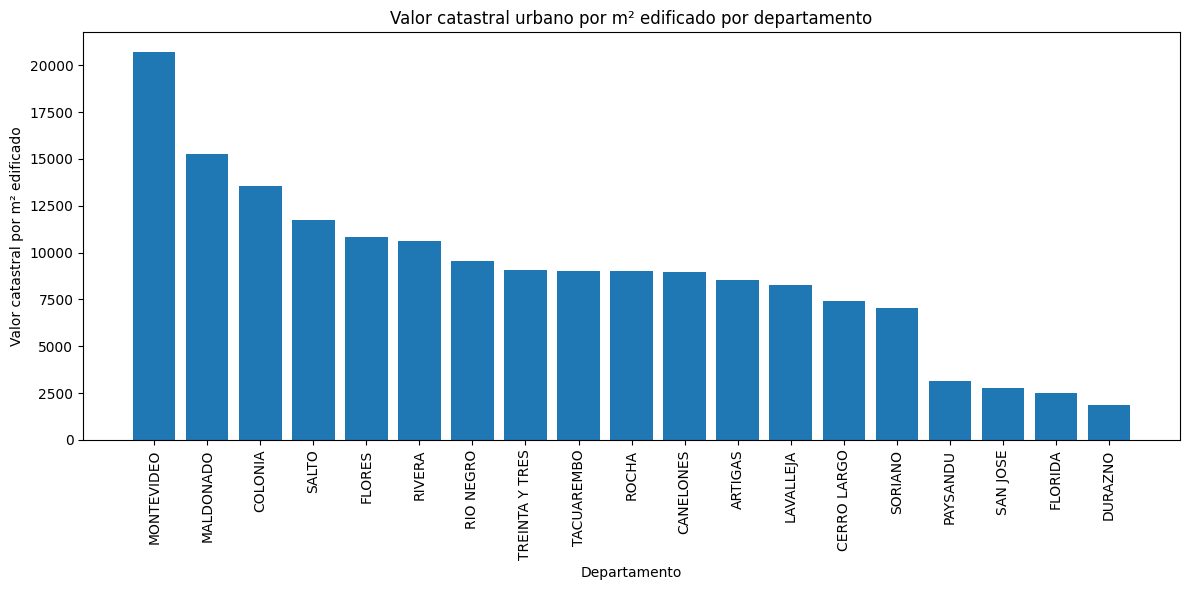

In [24]:
pdf_q2 = (
    spark.read
    .parquet(f"{ANL_PATH}/q2_valor_m2_edificado_departamento")
    .orderBy(col("valor_catastral_por_m2_edificado").desc())
    .toPandas()
)

plt.figure(figsize=(12, 6))
plt.bar(pdf_q2["departamento"], pdf_q2["valor_catastral_por_m2_edificado"])
plt.xticks(rotation=90)
plt.xlabel("Departamento")
plt.ylabel("Valor catastral por m² edificado")
plt.title("Valor catastral urbano por m² edificado por departamento")
plt.tight_layout()
plt.show()

### Visualización 3: Área construida total por destino

Se visualizan los principales destinos de construcción según área construida total.

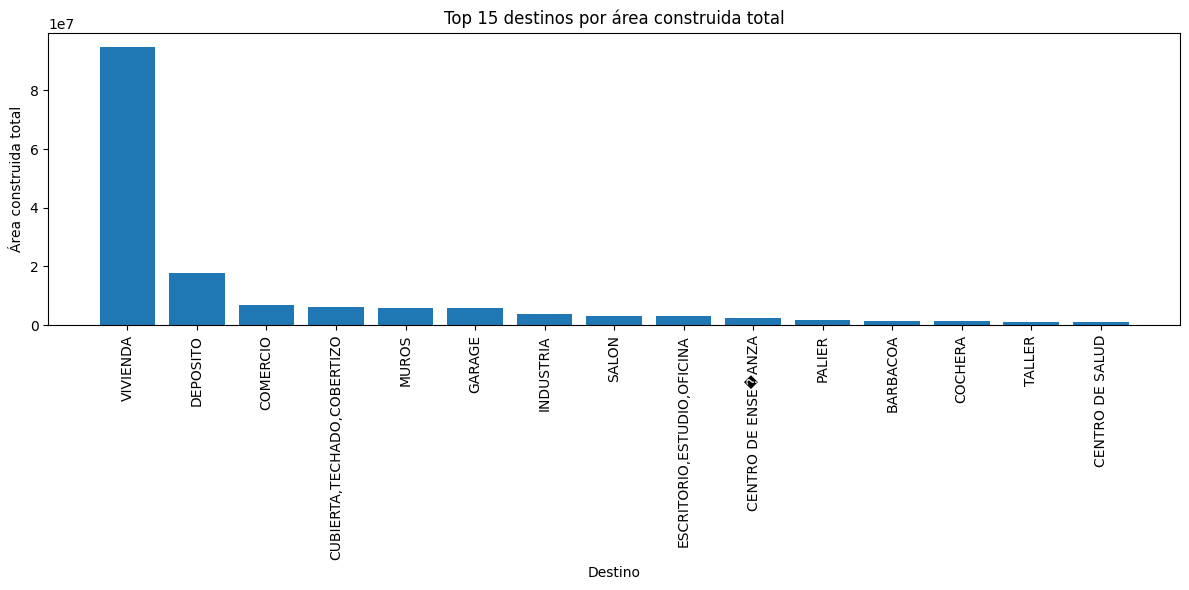

In [26]:
pdf_q3 = (
    spark.read
    .parquet(f"{ANL_PATH}/q3_area_construida_destino")
    .orderBy(col("area_construida_total").desc())
    .limit(15)
    .toPandas()
)

plt.figure(figsize=(12, 6))
plt.bar(pdf_q3["destino"], pdf_q3["area_construida_total"])
plt.xticks(rotation=90)
plt.xlabel("Destino")
plt.ylabel("Área construida total")
plt.title("Top 15 destinos por área construida total")
plt.tight_layout()
plt.show()

## 12. Conclusiones del análisis

A partir de las consultas analíticas realizadas sobre las tablas Hive del modelo de Catastro, se concluye que:

- Montevideo concentra el mayor valor catastral urbano total.
- Maldonado ocupa el segundo lugar en valor catastral urbano total y también presenta un valor elevado por metro cuadrado edificado.
- Canelones tiene una gran cantidad de padrones urbanos, aunque con menor valor promedio que Montevideo y Maldonado.
- El destino `VIVIENDA` concentra ampliamente la mayor área construida registrada.
- El estado de conservación más frecuente en las líneas de construcción es `Regular`.
- Tacuarembó, Salto y Paysandú concentran las mayores superficies rurales.
- Montevideo presenta un valor catastral rural por unidad de área muy superior al resto, aunque con baja superficie rural total.

Los resultados fueron guardados en la zona analítica `/anl/obligatorio_catastro`, completando el flujo del datalake desde la ingesta hasta la explotación analítica.